In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
X, y = make_classification(
    n_features=10, 
    n_samples=1000, 
    n_informative=4,
    n_redundant=6,
    n_repeated=0,
    n_classes=2, 
    random_state=42
)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [3]:
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

# default threshold will be 0.5 and as we decrease it our recall will increase.
# for here there is a default threshold 0.5 in which we can see our recall is very low and for the cancer detection model we can't afford,
# that risk that's why we need to increase our recall and for that we need to derecrease our threshold.

              precision    recall  f1-score   support

           0       0.66      0.69      0.67       122
           1       0.69      0.66      0.68       128

    accuracy                           0.68       250
   macro avg       0.68      0.68      0.68       250
weighted avg       0.68      0.68      0.68       250



In [4]:
# Here now we are looking on the probabilites and trying to increase recall also decrease threshold.

probabilities = model.predict_proba(X_test)[:,1]
probabilities

array([0.57822587, 0.52735143, 0.52549286, 0.42366894, 0.13841554,
       0.12313382, 0.46883093, 0.75948267, 0.0625359 , 0.35868659,
       0.11232103, 0.83728295, 0.89532679, 0.82659466, 0.45989201,
       0.1847224 , 0.67120632, 0.23166802, 0.44797747, 0.19607102,
       0.47034334, 0.94976287, 0.12254625, 0.60645741, 0.68401263,
       0.69154072, 0.74573154, 0.35445467, 0.71366823, 0.23600192,
       0.41372387, 0.31442238, 0.51846885, 0.67030839, 0.47785359,
       0.3046691 , 0.11323506, 0.21753596, 0.47609673, 0.82196242,
       0.12548248, 0.35859981, 0.46897845, 0.21401439, 0.23914749,
       0.55243292, 0.68077102, 0.2057241 , 0.39247397, 0.78390729,
       0.53617752, 0.84961668, 0.48942874, 0.64911008, 0.26780503,
       0.47479916, 0.72275676, 0.96093933, 0.84719638, 0.50530374,
       0.10504748, 0.92584106, 0.22096754, 0.46482437, 0.18064713,
       0.32954476, 0.82746705, 0.71344147, 0.03891063, 0.60762971,
       0.26349585, 0.33998991, 0.15936681, 0.28760272, 0.34200

In [5]:
# we are just assumming that 0.4 will be a okay threshold after consulting with the stakeholder as per their buget if their budget is high
# then we can decrease the threshold more as per the need and one more factor is that how much area  curved by ROC for particular threshold.

y_pred = (probabilities > 0.4)
y_pred

array([ True,  True,  True,  True, False, False,  True,  True, False,
       False, False,  True,  True,  True,  True, False,  True, False,
        True, False,  True,  True, False,  True,  True,  True,  True,
       False,  True, False,  True, False,  True,  True,  True, False,
       False, False,  True,  True, False, False,  True, False, False,
        True,  True, False, False,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True, False,  True, False,
        True, False, False,  True,  True, False,  True, False, False,
       False, False, False,  True,  True,  True,  True,  True,  True,
       False, False,  True, False,  True,  True,  True, False,  True,
        True, False,  True,  True,  True,  True,  True, False,  True,
        True, False, False,  True,  True,  True, False,  True,  True,
       False, False, False, False, False, False,  True, False,  True,
        True, False, False,  True, False,  True,  True,  True,  True,
       False, False,

In [6]:
y_pred.astype(int)

array([1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1])

In [7]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.75      0.57      0.65       122
           1       0.67      0.82      0.74       128

    accuracy                           0.70       250
   macro avg       0.71      0.70      0.69       250
weighted avg       0.71      0.70      0.70       250



In [8]:
# Now we can see here our recall has increase but at the same time our precision got decrase
# Now we will draw ROC curve

In [9]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, probabilities)
fpr[:5], tpr[:5], thresholds[:5]

(array([0.        , 0.        , 0.        , 0.00819672, 0.00819672]),
 array([0.       , 0.0078125, 0.265625 , 0.265625 , 0.2890625]),
 array([       inf, 0.97928246, 0.80890214, 0.80840719, 0.80207033]))

In [10]:
# as per skateholder demand and medical concers we want recall high

desired_recall = 0.9
closest_index = np.argmin(abs(tpr - desired_recall))
tpr[closest_index], thresholds[closest_index], fpr[closest_index]

(0.90625, 0.26349585272229664, 0.7049180327868853)

In [11]:
from sklearn.metrics import auc

area = auc(fpr,tpr)
area

0.764856557377049

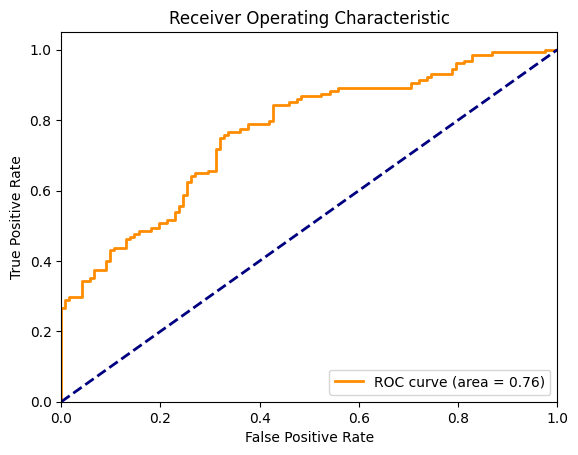

In [12]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [13]:
from xgboost import XGBRFClassifier

model = XGBRFClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       122
           1       0.93      0.89      0.91       128

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250



In [14]:
probabilities_xgb = model.predict_proba(X_test)[:,1]
tpr_xgb, fpr_xgb, thresholds_xgb = roc_curve(y_test, probabilities_xgb)
tpr_xgb[:5], fpr_xgb[:5], thresholds_xgb[:5]

(array([0., 0., 0., 0., 0.]),
 array([0.       , 0.0078125, 0.0390625, 0.0625   , 0.328125 ]),
 array([       inf, 0.880778  , 0.88072306, 0.8806107 , 0.8805558 ],
       dtype=float32))

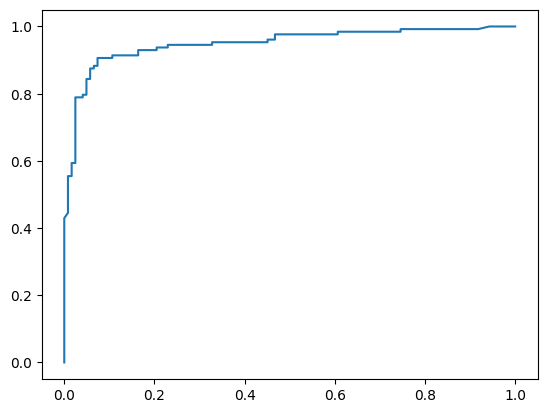

In [15]:
# Fix the variable order here
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, probabilities_xgb)

# Now AUC will be calculated correctly
area2 = auc(fpr_xgb, tpr_xgb)

# And the plot will be correct
plt.plot(fpr_xgb, tpr_xgb)

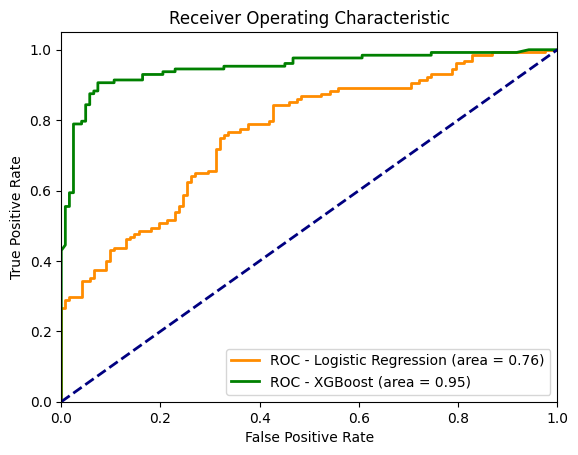

In [16]:
plt.figure()

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC - Logistic Regression (area = %0.2f)' % area)
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label='ROC - XGBoost (area = %0.2f)' % area2)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [17]:
desired_recall = 0.92

closest_index = np.argmin(abs(tpr_xgb-desired_recall))
tpr_xgb[closest_index], thresholds_xgb[closest_index], fpr_xgb[closest_index]

(0.9140625, 0.40193424, 0.10655737704918032)

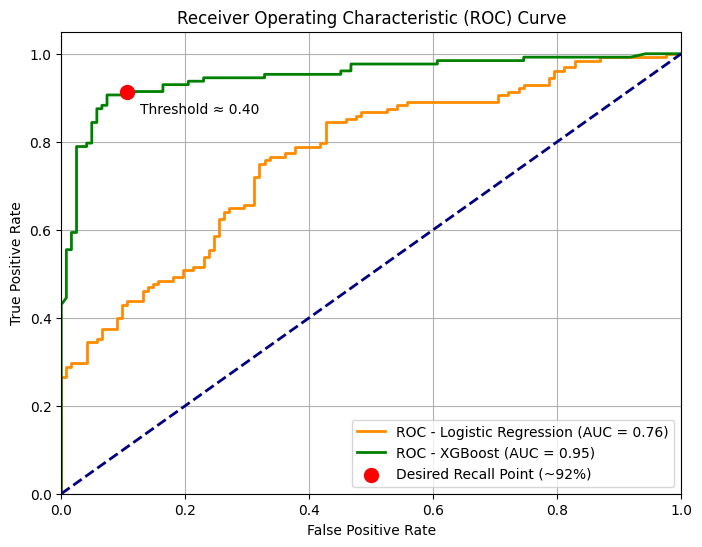

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- This is the same plotting code as before ---
plt.figure(figsize=(8, 6)) # Made the figure a bit bigger

# Plot ROC for Logistic Regression
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC - Logistic Regression (AUC = {area:.2f})')

# Plot ROC for XGBoost
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label=f'ROC - XGBoost (AUC = {area2:.2f})')

# Plot the random guess line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# --- NEW CODE TO HIGHLIGHT THE POINT ---

# 1. Find the coordinates for your desired point
desired_tpr = tpr_xgb[closest_index]
desired_fpr = fpr_xgb[closest_index]
desired_threshold = thresholds_xgb[closest_index]

# 2. Add a red dot on the XGBoost curve at that point
plt.scatter(desired_fpr, desired_tpr, color='red', s=100, zorder=5, label=f'Desired Recall Point (~92%)')
# s=100 makes the dot bigger, zorder=5 makes sure it's drawn on top

# 3. Optional: Add text to show the threshold
plt.text(desired_fpr + 0.02, desired_tpr - 0.05, f'Threshold ≈ {desired_threshold:.2f}')


# --- Final plot formatting ---
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid() # Adds a grid for easier reading
plt.show()

In [20]:
import numpy as np

# Set your new desired recall value
desired_recall = 0.92

# Find the index of the TPR value that is closest to your desired recall
closest_index = np.argmin(abs(tpr_xgb - desired_recall))

# Get the values at that index
tpr_at_point = tpr_xgb[closest_index]
threshold_at_point = thresholds_xgb[closest_index]
fpr_at_point = fpr_xgb[closest_index]

print(f"To achieve a recall of approximately {tpr_at_point:.2f}, you should use a threshold of around {threshold_at_point:.2f}.")
print(f"At this point, your False Positive Rate will be approximately {fpr_at_point:.2f}.")

To achieve a recall of approximately 0.91, you should use a threshold of around 0.40.
At this point, your False Positive Rate will be approximately 0.11.


In [21]:
# Use the threshold you just found
new_threshold = threshold_at_point 

# Get the probabilities from your model
probabilities_xgb = model.predict_proba(X_test)[:, 1]

# Make final predictions based on the new threshold
y_pred_final = (probabilities_xgb > new_threshold).astype(int)

# You can now create a new classification report to see the results
from sklearn.metrics import classification_report
print("--- Classification Report with New Threshold ---")
print(classification_report(y_test, y_pred_final))

--- Classification Report with New Threshold ---
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       122
           1       0.90      0.91      0.90       128

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250



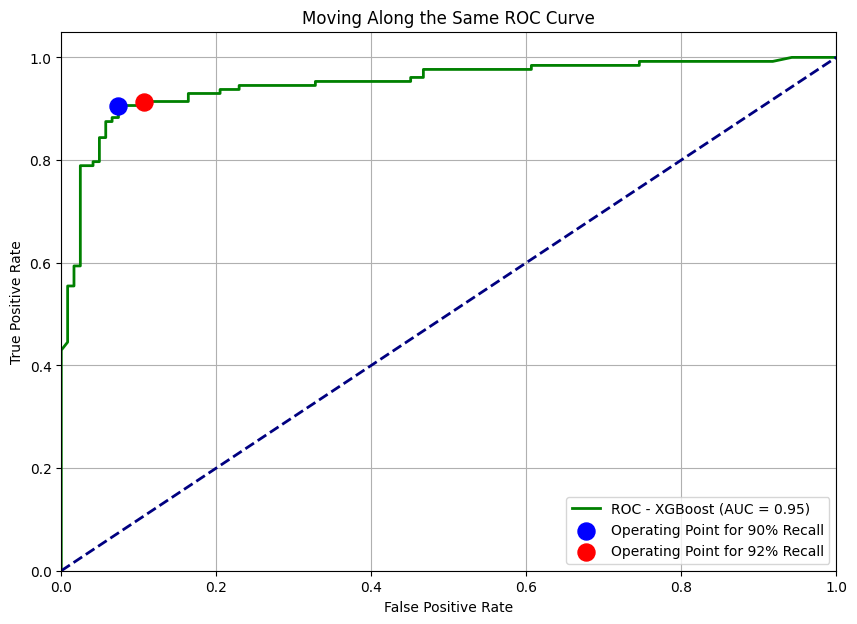

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- Find the point for 90% recall ---
desired_recall_90 = 0.90
closest_index_90 = np.argmin(abs(tpr_xgb - desired_recall_90))
fpr_90 = fpr_xgb[closest_index_90]
tpr_90 = tpr_xgb[closest_index_90]

# --- Find the point for 92% recall ---
desired_recall_92 = 0.92
closest_index_92 = np.argmin(abs(tpr_xgb - desired_recall_92))
fpr_92 = fpr_xgb[closest_index_92]
tpr_92 = tpr_xgb[closest_index_92]

# --- Plot the ROC Curve and both points ---
plt.figure(figsize=(10, 7))

# Plot the XGBoost ROC curve (the car's potential)
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label=f'ROC - XGBoost (AUC = {area2:.2f})')

# Plot the 90% recall point
plt.scatter(fpr_90, tpr_90, color='blue', s=150, zorder=5, label='Operating Point for 90% Recall')

# Plot the 92% recall point
plt.scatter(fpr_92, tpr_92, color='red', s=150, zorder=5, label='Operating Point for 92% Recall')

# Plot the random guess line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Final plot formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Moving Along the Same ROC Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()